In [ ]:
%%bash

if [ -d "sample_data" ]; then
    cd "sample_data"
    rm -r *
    git clone https://github.com/FrancescoLR02/ImageColorization.git .
    git checkout edamore
    mv * "/content"
    cd "/content"
    rm -rf "sample_data"
    gdown https://drive.google.com/uc?id=13a-E_18Vf0oHNNwdOo3G3_zXmZ9xGKVC
    unzip "DPO_dataset.zip"
    # pip install peft
else
    echo "sample_data not found"
fi

sample_data not found


# DPO on ECCV
### libraries

In [2]:
# eccv16 specific files and models
import ast
import os
import re
import subprocess
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from peft import LoraConfig
from sklearn.decomposition import PCA

from colorization.colorizers import (
    eccv16,
    load_img,
    postprocess_tens,
    preprocess_img,
    preprocess_img_ab,
)

# from dpo_train import *  # dpo_train contains DPO training functions
from dpo_train import build_model, train

### 1: preference dataset import (from FLR HuggingFace space)

In [3]:
# merge .csv
# Run the called script with arguments
arg1 = "DPO_dataset/test_results_DPO.csv"
subprocess.run(["python3", "DPO_Results.py", arg1])
pref = pd.read_csv("FinalResults.csv")
pref

,ImageID,"(T_A, T_B)",optA_img,optB_img,true_img,baseline_img,humanChoice,rejectionChoice
0,0,"(np.float64(0.3862087586055609), np.float64(0....",DPO_dataset/Img_A/A_0.png,DPO_dataset/Img_B/B_0.png,DPO_dataset/Img_true/Real_0.png,DPO_dataset/Img_baseline/Baseline_0.png,NaN,NaN
1,1,"(np.float64(0.29168722324909263), np.float64(0...",DPO_dataset/Img_A/A_1.png,DPO_dataset/Img_B/B_1.png,DPO_dataset/Img_true/Real_1.png,DPO_dataset/Img_baseline/Baseline_1.png,DPO_dataset/Img_B/B_1.png,DPO_dataset/Img_A/A_1.png
2,2,"(np.float64(0.250833915084797), np.float64(0.7...",DPO_dataset/Img_A/A_2.png,DPO_dataset/Img_B/B_2.png,DPO_dataset/Img_true/Real_2.png,DPO_dataset/Img_baseline/Baseline_2.png,NaN,NaN
3,3,"(np.float64(0.36056603902615647), np.float64(0...",DPO_dataset/Img_A/A_3.png,DPO_dataset/Img_B/B_3.png,DPO_dataset/Img_true/Real_3.png,DPO_dataset/Img_baseline/Baseline_3.png,NaN,NaN
4,4,"(np.float64(0.4559881344030133), np.float64(0....",DPO_dataset/Img_A/A_4.png,DPO_dataset/Img_B/B_4.png,DPO_dataset/Img_true/Real_4.png,DPO_dataset/Img_baseline/Baseline_4.png,DPO_dataset/Img_B/B_4.png,DPO_dataset/Img_A/A_4.png
...,...,...,...,...,...,...,...,...
795,795,"(np.float64(0.28736080173700607), np.float64(0...",DPO_dataset/Img_A/A_795.png,DPO_dataset/Img_B/B_795.png,DPO_dataset/Img_true/Real_795.png,DPO_dataset/Img_baseline/Baseline_795.png,NaN,NaN
796,796,"(np.float64(0.365406169937874), np.float64(0.6...",DPO_dataset/Img_A/A_796.png,DPO_dataset/Img_B/B_796.png,DPO_dataset/Img_true/Real_796.png,DPO_dataset/Img_baseline/Baseline_796.png,DPO_dataset/Img_B/B_796.png,DPO_dataset/Img_A/A_796.png
797,797,"(np.float64(0.30429566032508876), np.float64(0...",DPO_dataset/Img_A/A_797.png,DPO_dataset/Img_B/B_797.png,DPO_dataset/Img_true/Real_797.png,DPO_dataset/Img_baseline/Baseline_797.png,NaN,NaN
798,798,"(np.float64(0.20233095074911997), np.float64(0...",DPO_dataset/Img_A/A_798.png,DPO_dataset/Img_B/B_798.png,DPO_dataset/Img_true/Real_798.png,DPO_dataset/Img_baseline/Baseline_798.png,NaN,NaN


In [4]:
pref = pref.dropna()
pref

,ImageID,"(T_A, T_B)",optA_img,optB_img,true_img,baseline_img,humanChoice,rejectionChoice
1,1,"(np.float64(0.29168722324909263), np.float64(0...",DPO_dataset/Img_A/A_1.png,DPO_dataset/Img_B/B_1.png,DPO_dataset/Img_true/Real_1.png,DPO_dataset/Img_baseline/Baseline_1.png,DPO_dataset/Img_B/B_1.png,DPO_dataset/Img_A/A_1.png
4,4,"(np.float64(0.4559881344030133), np.float64(0....",DPO_dataset/Img_A/A_4.png,DPO_dataset/Img_B/B_4.png,DPO_dataset/Img_true/Real_4.png,DPO_dataset/Img_baseline/Baseline_4.png,DPO_dataset/Img_B/B_4.png,DPO_dataset/Img_A/A_4.png
6,6,"(np.float64(0.4862326521250368), np.float64(0....",DPO_dataset/Img_A/A_6.png,DPO_dataset/Img_B/B_6.png,DPO_dataset/Img_true/Real_6.png,DPO_dataset/Img_baseline/Baseline_6.png,DPO_dataset/Img_A/A_6.png,DPO_dataset/Img_B/B_6.png
13,13,"(np.float64(0.4197744250464728), np.float64(0....",DPO_dataset/Img_A/A_13.png,DPO_dataset/Img_B/B_13.png,DPO_dataset/Img_true/Real_13.png,DPO_dataset/Img_baseline/Baseline_13.png,DPO_dataset/Img_B/B_13.png,DPO_dataset/Img_B/B_13.png
15,15,"(np.float64(0.2294708296371551), np.float64(0....",DPO_dataset/Img_A/A_15.png,DPO_dataset/Img_B/B_15.png,DPO_dataset/Img_true/Real_15.png,DPO_dataset/Img_baseline/Baseline_15.png,DPO_dataset/Img_B/B_15.png,DPO_dataset/Img_B/B_15.png
...,...,...,...,...,...,...,...,...
780,780,"(np.float64(0.39344487433209874), np.float64(0...",DPO_dataset/Img_A/A_780.png,DPO_dataset/Img_B/B_780.png,DPO_dataset/Img_true/Real_780.png,DPO_dataset/Img_baseline/Baseline_780.png,DPO_dataset/Img_B/B_780.png,DPO_dataset/Img_B/B_780.png
781,781,"(np.float64(0.23786743978583713), np.float64(0...",DPO_dataset/Img_A/A_781.png,DPO_dataset/Img_B/B_781.png,DPO_dataset/Img_true/Real_781.png,DPO_dataset/Img_baseline/Baseline_781.png,DPO_dataset/Img_A/A_781.png,DPO_dataset/Img_A/A_781.png
788,788,"(np.float64(0.2652327762549585), np.float64(0....",DPO_dataset/Img_A/A_788.png,DPO_dataset/Img_B/B_788.png,DPO_dataset/Img_true/Real_788.png,DPO_dataset/Img_baseline/Baseline_788.png,DPO_dataset/Img_A/A_788.png,DPO_dataset/Img_A/A_788.png
790,790,"(np.float64(0.3435436056828766), np.float64(0....",DPO_dataset/Img_A/A_790.png,DPO_dataset/Img_B/B_790.png,DPO_dataset/Img_true/Real_790.png,DPO_dataset/Img_baseline/Baseline_790.png,DPO_dataset/Img_B/B_790.png,DPO_dataset/Img_B/B_790.png


### 1.1: temperature preference distribution (probably useless but let's look at it regardless)

303 303


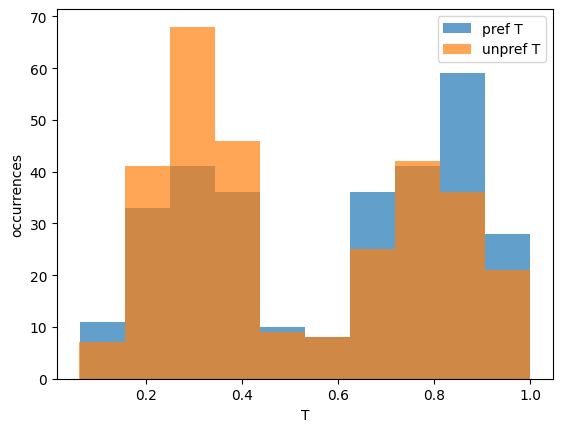

In [5]:
# extract temperatures
temp = pref["(T_A, T_B)"]
temperatures = []
for idx in range(len(temp)):
    s = temp.iloc[idx]
    cleaned = re.sub(r"np\.float64\(([^)]+)\)", r"\1", s)
    result = ast.literal_eval(cleaned)
    temperatures.append(result)

# extract preferences
preferences = pref["humanChoice"]
temp_index = []
spref_index = []
for idx in range(len(preferences)):
    # B is preferred
    if preferences.iloc[idx].find("Img_A") == -1:
        temp_index.append(1)
        spref_index.append(0)
    # A is preferred
    if preferences.iloc[idx].find("Img_B") == -1:
        temp_index.append(0)
        spref_index.append(1)

# sanity check
print(len(temperatures), len(preferences))

# extract the distribution
pref_temp = np.zeros(len(temperatures))
spref_temp = np.zeros(len(temperatures))

for idx in range(len(pref_temp)):
    pref_temp[idx] = temperatures[idx][temp_index[idx]]
    spref_temp[idx] = temperatures[idx][spref_index[idx]]

# plot logic
plt.hist(pref_temp, alpha=0.7, label="pref T")
plt.hist(spref_temp, alpha=0.7, label="unpref T")
plt.legend()
plt.ylabel("occurrences")
plt.xlabel("T")
plt.show()

### 1.2: Preference exploration

In [6]:
# Count preferences
cnt = 0
for choice in pref["humanChoice"]:
    if choice.find("Img_A") != -1:
        cnt += 1
tot = len(pref["humanChoice"])
print(f"Img A preferences: {cnt}, in %: {cnt / tot * 100}")
print(
    f"Img B preferences: {len(pref['humanChoice']) - cnt}, in %: {float(len(pref['humanChoice']) - cnt) / tot * 100}"
)

Img A preferences: 131, in %: 43.23432343234324
Img B preferences: 172, in %: 56.76567656765676


Imported lens: 303 303 303


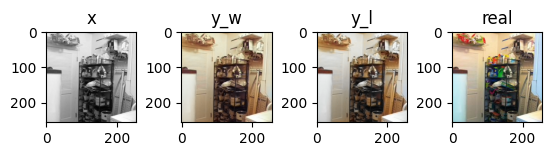

In [7]:
# read the preference
x = []
x_training = []
y_w = []
y_l = []
real = []
real_ab = []

for idx, row in pref.iterrows():
    y_w.append(load_img(row["humanChoice"]))
    y_l.append(load_img(row["rejectionChoice"]))
    x.append(
        preprocess_img(load_img(f"DPO_dataset/Img_true/Real_{row['ImageID']}.png"))[
            1
        ].squeeze()
    )
    x_training.append(
        preprocess_img(load_img(f"DPO_dataset/Img_true/Real_{row['ImageID']}.png"))[1][
            0
        ]
    )
    real_ab.append(
        preprocess_img_ab(load_img(f"DPO_dataset/Img_true/Real_{row['ImageID']}.png"))[
            1
        ]
    )
    real.append(load_img(f"DPO_dataset/Img_true/Real_{row['ImageID']}.png"))

print("Imported lens:", len(x), len(y_w), len(y_l))

fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4)
fig.subplots_adjust(wspace=0.5)

index = 69
ax1.imshow(x[index], cmap="gray")
ax2.imshow(y_w[index])
ax3.imshow(y_l[index])
ax4.imshow(real[index])

ax1.set_title("x")
ax2.set_title("y_w")
ax3.set_title("y_l")
ax4.set_title("real")

plt.show()

In [8]:
# format the preference dataset as list of dicts of np arrays
samples = [
    {
        "l": x_training[idx],
        "chosen_ab": preprocess_img_ab(y_w[idx])[1],  # element 0 is original-shaped
        "rejected_ab": preprocess_img_ab(y_l[idx])[1],  # element 1 is reshaped
    }
    for idx in range(len(x))
]
samples[0]

{'l': tensor([[[95.2551, 95.2551, 95.6035,  ..., 38.5129, 38.5129, 39.3165],
          [95.2551, 95.2551, 95.6035,  ..., 46.2939, 44.6769, 43.8644],
          [95.3797, 95.7280, 95.7280,  ..., 49.4698, 47.8732, 46.6965],
          ...,
          [36.0030, 37.6625, 39.6969,  ..., 44.7340, 38.9214, 32.6390],
          [64.2665, 43.8360, 23.8596,  ..., 51.4683, 53.0288, 56.4743],
          [82.3686, 64.6428, 40.7089,  ..., 46.9947, 51.0589, 58.3358]]]),
 'chosen_ab': tensor([[[-5.2877, -5.2877, -5.2838,  ...,  9.6851,  9.6851, 10.2485],
          [-5.2877, -5.2877, -5.2838,  ...,  9.7059,  9.7842,  9.8246],
          [-5.2877, -5.2838, -5.2838,  ..., 10.1435, 10.2189,  9.6869],
          ...,
          [-4.7892, -4.7915, -4.9388,  ...,  1.2886,  1.0039,  1.3534],
          [-5.2992, -4.9352, -4.9176,  ...,  0.8744,  2.2419,  2.0162],
          [-5.3357, -5.1446, -5.3772,  ...,  0.9555,  2.2872,  2.3805]],
 
         [[-0.7347, -0.7347, -0.7343,  ...,  6.3019,  6.3019,  5.8788],
          

## 2: Distribution evaluation

Explained variance ratio: [0.32612038 0.12835115]


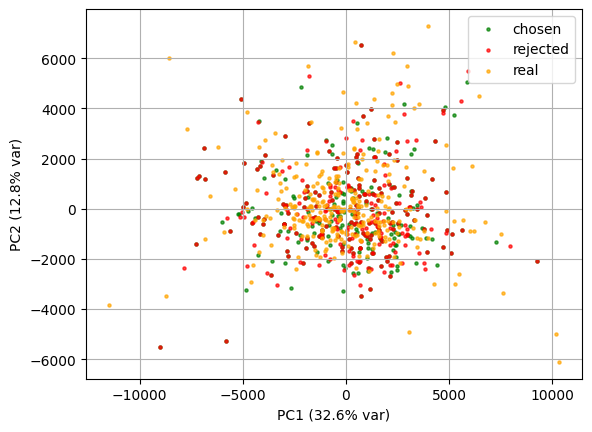

In [9]:
# Flatten each ab image to a 1D vector (2 * H * W,)
chosen_vecs = [
    samples[idx]["chosen_ab"].numpy().reshape(-1) for idx in range(len(samples))
]
rejected_vecs = [
    samples[idx]["rejected_ab"].numpy().reshape(-1) for idx in range(len(samples))
]
real_vecs = [real_ab[idx].reshape(-1) for idx in range(len(real))]

all_vecs = np.stack(chosen_vecs + rejected_vecs + real_vecs)  # (2N, 2*H*W)

# Fit PCA on all samples together so both sets share the same projection
pca = PCA(n_components=2)
all_2d = pca.fit_transform(all_vecs)

n = len(chosen_vecs)
chosen_2d = all_2d[:n]
rejected_2d = all_2d[n : 2 * n]
real_2d = all_2d[2 * n :]

print(f"Explained variance ratio: {pca.explained_variance_ratio_}")
size = 5  # dotsize
plt.scatter(
    chosen_2d[:, 0], chosen_2d[:, 1], c="green", label="chosen", alpha=0.7, s=size
)
plt.scatter(
    rejected_2d[:, 0], rejected_2d[:, 1], c="red", label="rejected", alpha=0.7, s=size
)
plt.scatter(real_2d[:, 0], real_2d[:, 1], c="orange", label="real", alpha=0.7, s=size)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} var)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} var)")
plt.legend()
plt.grid()
plt.show()

## 3: Retraining part of the model with DPO

In [10]:
# build model takes as input
# - desired model to retrain
# - a list of target layers (we train only the rightmost part of the model, sparing compute time)
model_name = "eccv16"
lora_layers = ["model8.6"]
finetune_layers = ["model_out"]  # ,'model_out']
model = build_model(model_name, lora_layers, finetune_layers, pretrained=True)
model

Frozen: 32,235,385  |  Trainable: 5,178


ECCVGenerator(
  (model1): Sequential(
    (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (model2): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(128, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (model3): Sequential(
    (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): Conv2d(256, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (5): ReLU(inplace=Tru

In [11]:
# check for shapes
sample = samples[0]
print(sample["l"].shape)  # expect (1, 256, 256)
print(sample["chosen_ab"].shape)  # expect (2, 256, 256)
print(sample["rejected_ab"].shape)  # expect (2, 256, 256)

torch.Size([1, 256, 256])
torch.Size([2, 256, 256])
torch.Size([2, 256, 256])


In [13]:
# train function handles automatically the loss and the data
# original model is the standard model that DPO uses as reference
original_model = eccv16(pretrained=True).eval()
epochs = 1
batch_size = 1
lr = 1e-5
beta = 0.1

file_name = Path("dpo_trained_020526.pth")

if not file_name.exists():
    file_name.touch()
    print("training model...")
    new_model = train(samples, model, original_model, epochs, batch_size, lr, beta)
    torch.save(new_model.state_dict(), file_name)
else:
    new_model = build_model(model_name, lora_layers, finetune_layers, pretrained=False)
    new_model.load_state_dict(torch.load(file_name, map_location="cpu"))
    print("Loaded model!")

training model...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Epochs:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch 1/1:   0%|          | 0/303 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Epoch 1/1  loss=0.6931


In [ ]:
new_model.eval()

ECCVGenerator(
  (model1): Sequential(
    (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (model2): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(128, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (model3): Sequential(
    (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): Conv2d(256, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (5): ReLU(inplace=Tru

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
indices = np.random.choice(pref.index, 5)
check = []
for idx in indices:
    l_orig, l_rs = preprocess_img(load_img(f"DPO_dataset/Img_true/Real_{idx}.png"))

    with torch.no_grad():
        ab_pred = new_model(l_orig.to(device))  # post-DPO
        ab_orig = original_model(l_orig.to(device))  # true original pretrained model

    print(f"generated {idx}")
    entry = {"l": l_orig, "ab_pred": ab_pred, "ab_orig": ab_orig}
    check.append(entry)

    fig, (ax1, ax2) = plt.subplots(1, 2)
    fig.subplots_adjust(wspace=0.5)
    ax1.imshow(postprocess_tens(l_orig, ab_pred))
    ax2.imshow(postprocess_tens(l_orig, ab_orig))
    ax1.set_title("post DPO")
    ax2.set_title("original model")
    plt.savefig(f"DPO/DPO_check_{idx}.png")
    plt.show()

RuntimeError: Input type (torch.FloatTensor) and weight type (torch.cuda.FloatTensor) should be the same or input should be a MKLDNN tensor and weight is a dense tensor